# Bayesian Marketing Mix Modeling, from scratch — Part 1: build it yourself in PyMC

**Goal of this notebook:** understand *why* a Bayesian geo-level MMM (the kind
[Google's Meridian](https://github.com/google/meridian) fits) is built the way
it is, by building a simplified version of it ourselves in
[PyMC](https://www.pymc.io/), one concept at a time.


### Roadmap

1. Understand the data: what a geo-level marketing panel looks like.
2. Two core transformations: **adstock** (carryover) and **saturation**
   (diminishing returns) — understood in isolation, on a toy series, before
   they get buried inside a big model.
3. Why (and how) we scale the data before modeling — and a real bug this
   project already hit because of skipping this step.
4. Build the model: geo-hierarchical priors, the media transformation
   pipeline, the likelihood.
5. Fit it (MCMC) and check whether we can trust the fit (trace plots, R-hat,
   ESS, divergences).
6. Posterior predictive checks: does the fitted model reproduce the data?
7. Turn the abstract parameters into a business answer: incremental
   conversions and ROI per channel.



## 1. Setup

In [1]:
import pytensor
pytensor.config.cxx = ""

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az

RNG = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (9, 4)

print("pymc      ", pm.__version__)
print("arviz     ", az.__version__)

pymc       5.28.5
arviz      0.23.4


## 2. Understand the data

We're using Meridian's own simulated dataset,
[`geo_all_channels.csv`](https://github.com/google/meridian/tree/main/meridian/data/simulated_data/csv):
a **panel** of 40 geos (regions) over 156 weeks. "Panel" just means every geo
has its own full time series — this is what makes a *geo-level* MMM possible:
instead of one national time series of ~156 points (barely enough to fit a
handful of parameters), we have 40 × 156 = 6,240 observations, and — more
importantly — 40 independent "replicates" of how media affects the outcome.
That's what lets a hierarchical model estimate a channel's effect much more
precisely than a single national series ever could.

In [4]:
df = pd.read_csv("../data/geo_all_channels.csv")
df["time"] = pd.to_datetime(df["time"])
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")])

print(f"{df.shape[0]} rows  ({df['geo'].nunique()} geos x {df['time'].nunique()} weeks)")
df.head()

6240 rows  (40 geos x 156 weeks)


,geo,time,Channel0_impression,Channel1_impression,Channel2_impression,Channel3_impression,Channel4_impression,competitor_sales_control,sentiment_score_control,Channel0_spend,Channel1_spend,Channel2_spend,Channel3_spend,Channel4_spend,Organic_channel0_impression,Promo,conversions,revenue_per_conversion,population
0,Geo0,2021-01-25,280668,0,0,470611,108010,-1.338765,0.115581,2058.0608,0.00000,0.00000,3667.3965,841.6044,97320,0.000000,1954576.8,0.020055,136670.94
1,Geo0,2021-02-01,366206,182108,19825,527702,252506,0.893645,0.944224,2685.2874,1755.74540,147.31808,4112.2974,1967.5044,201441,0.000000,2064249.6,0.020103,136670.94
2,Geo0,2021-02-08,197565,230170,0,393618,184061,-0.284549,-1.290579,1448.6895,2219.12230,0.00000,3067.4023,1434.1870,0,0.683819,2086382.8,0.019929,136670.94
3,Geo0,2021-02-15,140990,66643,0,326034,201729,-1.034740,-1.084514,1033.8406,642.52057,0.00000,2540.7310,1571.8545,0,1.289055,2826431.5,0.019987,136670.94
4,Geo0,2021-02-22,399116,164991,0,381982,153973,-0.319276,-0.017503,2926.6072,1590.71640,0.00000,2976.7249,1199.7440,0,0.227739,3551929.2,0.020000,136670.94


In [5]:
print("Columns and what they represent:\n")
roles = {
    "geo": "region identifier (panel unit)",
    "time": "week (panel time index)",
    "population": "geo population — used to scale everything to a fair per-capita basis",
    "conversions": "the KPI we're modeling (non-revenue KPI; see revenue_per_conversion)",
    "revenue_per_conversion": "$ per conversion, to translate KPI back into revenue for ROI",
    "Promo": "a non-media treatment (a promotion flag/intensity) — not modeled in this notebook",
    "Organic_channel0_impression": "organic (unpaid) media — not modeled in this notebook",
    "competitor_sales_control": "control variable: competitor activity",
    "sentiment_score_control": "control variable: brand sentiment",
}
for i in range(5):
    roles[f"Channel{i}_impression"] = f"paid media channel {i}, in impressions (the 'media' variable)"
    roles[f"Channel{i}_spend"] = f"paid media channel {i}, in $ spend (used for cost/ROI, not as the media variable itself)"

for c in df.columns:
    print(f"  {c:32s} {roles.get(c, '')}")

Columns and what they represent:

  geo                              region identifier (panel unit)
  time                             week (panel time index)
  Channel0_impression              paid media channel 0, in impressions (the 'media' variable)
  Channel1_impression              paid media channel 1, in impressions (the 'media' variable)
  Channel2_impression              paid media channel 2, in impressions (the 'media' variable)
  Channel3_impression              paid media channel 3, in impressions (the 'media' variable)
  Channel4_impression              paid media channel 4, in impressions (the 'media' variable)
  competitor_sales_control         control variable: competitor activity
  sentiment_score_control          control variable: brand sentiment
  Channel0_spend                   paid media channel 0, in $ spend (used for cost/ROI, not as the media variable itself)
  Channel1_spend                   paid media channel 1, in $ spend (used for cost/ROI, not as the med

**Media, in impressions or in dollars?** Each channel has both an
`_impression` and a `_spend` column. Meridian's convention — and the one we'll
follow — is to run the *media transformation pipeline* (adstock + saturation)
on a quantity that reflects actual audience exposure (impressions, reach,
etc.), and to bring spend back in only afterwards, to translate the model's
output into ROI/CPIK. The reasoning: audiences respond to being *exposed* to
advertising, not to how many dollars were spent generating that exposure —
and the price of an impression drifts over time and across geos (auctions,
inventory, seasonality), so a dollar today isn't the same "dose" as a dollar
last year. Modeling on spend directly folds that price drift silently into
the estimated effect curve.

We'll use **impressions** as the media variable and keep `_spend` around
separately for the ROI calculation at the end.

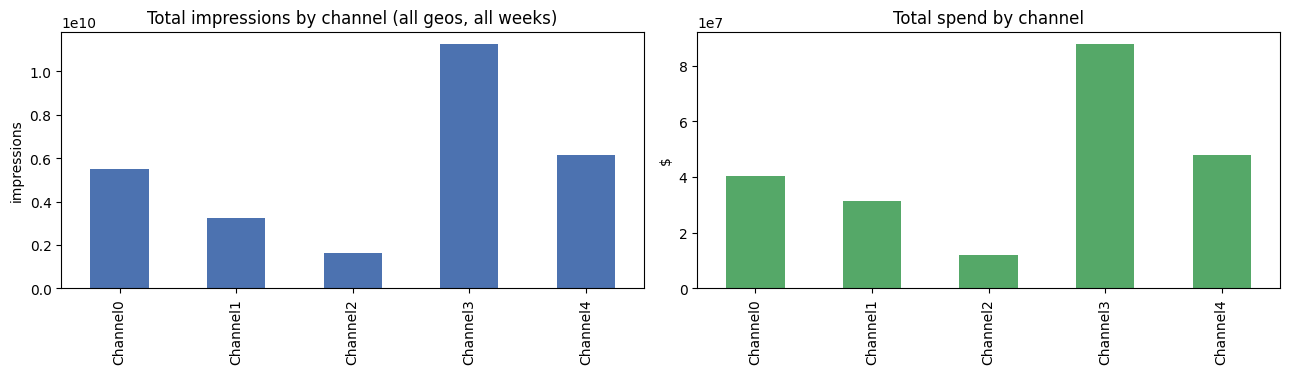

Share of weeks with ZERO impressions, by channel (channels are run in bursts, not continuously):
Channel0    0.12
Channel1    0.28
Channel2    0.64
Channel3    0.03
Channel4    0.13
dtype: float64


In [6]:
media_channels = [f"Channel{i}" for i in range(5)]
impression_cols = [f"{c}_impression" for c in media_channels]
spend_cols = [f"{c}_spend" for c in media_channels]
control_cols = ["competitor_sales_control", "sentiment_score_control"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

total_impr = df[impression_cols].sum().rename(lambda c: c.replace("_impression", ""))
total_impr.plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Total impressions by channel (all geos, all weeks)")
axes[0].set_ylabel("impressions")

total_spend = df[spend_cols].sum().rename(lambda c: c.replace("_spend", ""))
total_spend.plot.bar(ax=axes[1], color="#55A868")
axes[1].set_title("Total spend by channel")
axes[1].set_ylabel("$")
plt.tight_layout()
plt.show()

zero_share = (df[impression_cols] == 0).mean().rename(lambda c: c.replace("_impression", ""))
print("Share of weeks with ZERO impressions, by channel (channels are run in bursts, not continuously):")
print(zero_share.round(2))

Two things worth noticing in that last cell, because both come back later:

- **Channel budgets are very unequal** (`Channel3` dominates spend). A model
  that isn't told anything about this will have very different amounts of
  information to learn each channel's effect from.
- **Every channel has weeks of exactly zero activity** — these are flighted
  campaigns, not always-on. `Channel2` in particular is off more than half
  the time. This matters mechanically in Section 5: if we're not careful, a
  channel that's mostly zero can make a scaling calculation divide by zero.

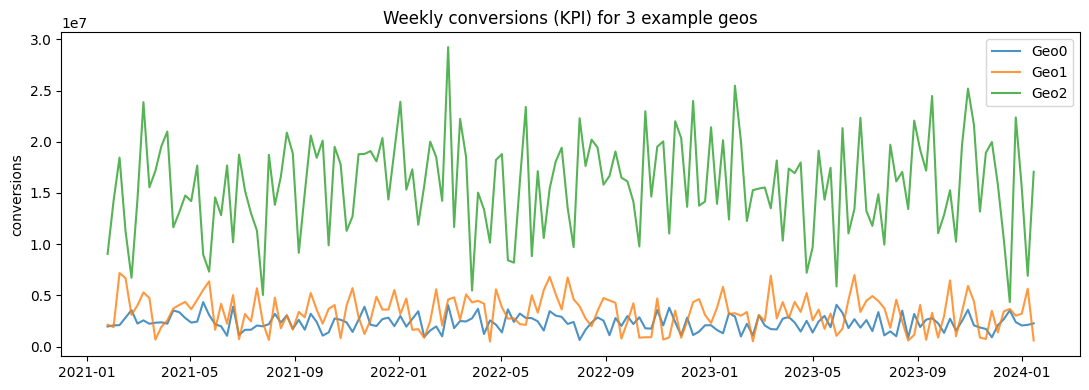

Geo population ranges from 136,671 to 994,049 (7.3x difference)
This alone explains a lot of the level difference between geos above --
bigger geos have proportionally more of everything (spend AND conversions).


In [7]:
example_geos = ["Geo0", "Geo1", "Geo2"]
fig, ax = plt.subplots(figsize=(11, 4))
for g in example_geos:
    sub = df[df["geo"] == g].sort_values("time")
    ax.plot(sub["time"], sub["conversions"], label=g, alpha=0.8)
ax.set_title("Weekly conversions (KPI) for 3 example geos")
ax.set_ylabel("conversions")
ax.legend()
plt.tight_layout()
plt.show()

pop = df.drop_duplicates("geo")["population"]
print(f"Geo population ranges from {pop.min():,.0f} to {pop.max():,.0f} "
      f"({pop.max()/pop.min():.1f}x difference)")
print("This alone explains a lot of the level difference between geos above --")
print("bigger geos have proportionally more of everything (spend AND conversions).")

In [8]:
def geometric_adstock(x, alpha, l_max):
    """Geometric adstock: effective_t = sum_{i=0}^{l_max-1} alpha^i * x_{t-i},
    with weights normalized to sum to 1.

    x: pytensor tensor, shape (n_times, n_geos, n_channels)
    alpha: pytensor tensor, shape (n_channels,), each in [0, 1]
    Returns a tensor of the same shape as x.

    Implementation note: l_max is a small, fixed Python integer (not a
    symbolic loop count), so we unroll the sum as l_max shifted-and-scaled
    copies of x. This is both simpler and much faster in PyMC than using
    pytensor.scan for such a short window.
    """
    lags = pt.arange(l_max, dtype="float64")
    weights = alpha[None, :] ** lags[:, None]                # (l_max, n_channels)
    weights = weights / weights.sum(axis=0, keepdims=True)   # normalize

    n_times = x.shape[0]
    pad = pt.zeros((l_max - 1, x.shape[1], x.shape[2]))
    padded = pt.concatenate([pad, x], axis=0)

    out = pt.zeros_like(x)
    for lag in range(l_max):
        shifted = padded[(l_max - 1 - lag):(l_max - 1 - lag) + n_times]
        out = out + shifted * weights[lag][None, None, :]
    return out


def hill_saturation(x, ec, slope):
    """Hill function: x^slope / (x^slope + ec^slope).

    `ec` ("half-saturation") is the media level at which the effect is at
    50% of its maximum. `slope` controls how sharp the transition is.
    Output is always in [0, 1) -- it's a *shape*, not a magnitude; the
    magnitude comes from a separate coefficient multiplied in afterwards.
    """
    return x**slope / (x**slope + ec**slope)

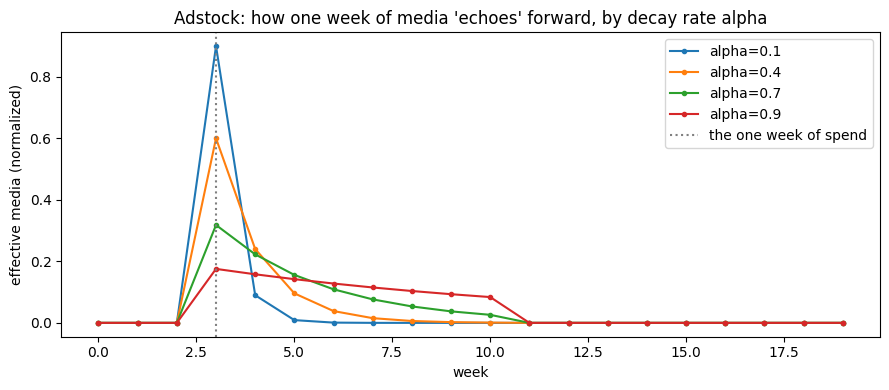

alpha near 0  -> almost no carryover, effect is basically same-week only
alpha near 1  -> long, slow-fading carryover across many weeks


In [ ]:
# Adstock decay Fucntion Test


import pytensor

weeks = np.arange(20)
spike = np.zeros((20, 1, 1))
spike[3, 0, 0] = 1.0 

x_sym = pt.tensor3("x")
alpha_sym = pt.vector("alpha")
adstock_fn = pytensor.function([x_sym, alpha_sym], geometric_adstock(x_sym, alpha_sym, l_max=8))

fig, ax = plt.subplots(figsize=(9, 4))
for a in [0.1, 0.4, 0.7, 0.9]:
    curve = adstock_fn(spike, np.array([a]))[:, 0, 0]
    ax.plot(weeks, curve, marker="o", markersize=3, label=f"alpha={a}")
ax.axvline(3, color="grey", linestyle=":", label="the one week of spend")
ax.set_title("Adstock: how one week of media 'echoes' forward, by decay rate alpha")
ax.set_xlabel("week")
ax.set_ylabel("effective media (normalized)")
ax.legend()
plt.tight_layout()
plt.show()
print("alpha near 0  -> almost no carryover, effect is basically same-week only")
print("alpha near 1  -> long, slow-fading carryover across many weeks")

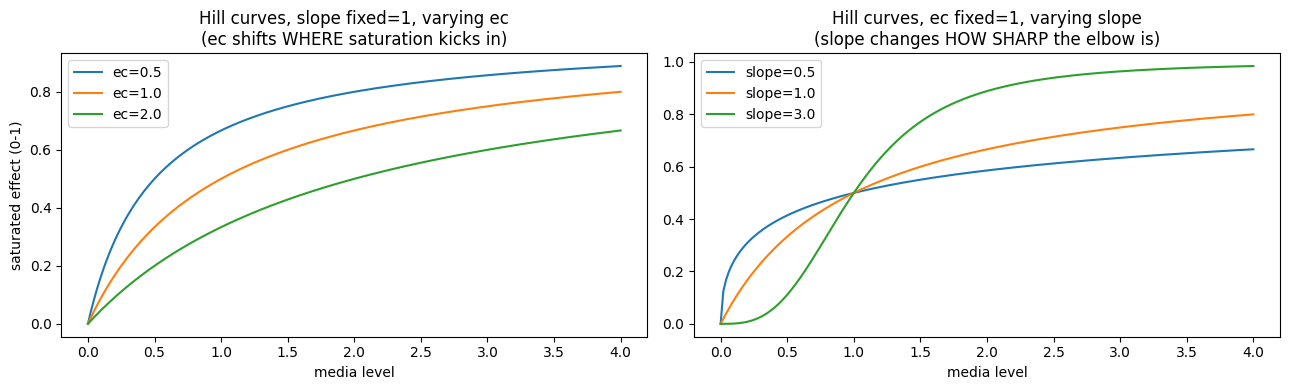

In [ ]:
#  Saturation Function Test
x_grid = np.linspace(0, 4, 200)
x_sat = pt.vector("x_sat")
ec_sym = pt.scalar("ec")
slope_sym = pt.scalar("slope")
hill_fn = pytensor.function([x_sat, ec_sym, slope_sym], hill_saturation(x_sat, ec_sym, slope_sym))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ec in [0.5, 1.0, 2.0]:
    axes[0].plot(x_grid, hill_fn(x_grid, ec, 1.0), label=f"ec={ec}")
axes[0].set_title("Hill curves, slope fixed=1, varying ec\n(ec shifts WHERE saturation kicks in)")
axes[0].legend(); axes[0].set_xlabel("media level"); axes[0].set_ylabel("saturated effect (0-1)")

for slope in [0.5, 1.0, 3.0]:
    axes[1].plot(x_grid, hill_fn(x_grid, 1.0, slope), label=f"slope={slope}")
axes[1].set_title("Hill curves, ec fixed=1, varying slope\n(slope changes HOW SHARP the elbow is)")
axes[1].legend(); axes[1].set_xlabel("media level")
plt.tight_layout()
plt.show()

Notice the media level on the x-axis is a small number (0-4), not raw
impression counts in the hundreds of thousands. That's the point of Section 4
below: before Hill saturation can be applied, media needs to be rescaled so
that `ec` (centered around ~1 in these plots) is a meaningful, comparable
number across channels of very different sizes. This is exactly the step the
original notebook skipped.

In [ ]:
geos = sorted(df["geo"].unique(), key=lambda s: int(s.replace("Geo", "")))
times = sorted(df["time"].unique())
n_geos, n_times, n_channels, n_controls = len(geos), len(times), len(media_channels), len(control_cols)

def pivot(col):
    """(week, geo) matrix, with geo/time order matching `geos` / `times`."""
    return (
        df.pivot(index="time", columns="geo", values=col)
        .reindex(index=times, columns=geos)
        .values
    )

population = df.drop_duplicates("geo").set_index("geo").reindex(geos)["population"].values 
media_raw = np.stack([pivot(c) for c in impression_cols], axis=-1)    
spend_raw = np.stack([pivot(c) for c in spend_cols], axis=-1)    
controls_raw = np.stack([pivot(c) for c in control_cols], axis=-1)      
y_raw = pivot("conversions")                                       
revenue_per_conv = df["revenue_per_conversion"].mean() 
print("media_raw   ", media_raw.shape)
print("controls_raw", controls_raw.shape)
print("y_raw       ", y_raw.shape)

media_raw    (156, 40, 5)
controls_raw (156, 40, 2)
y_raw        (156, 40)


In [ ]:

media_percap = media_raw / population[None, :, None]
media_percap_nonzero = np.where(media_percap == 0, np.nan, media_percap)
median_percap_m = np.nanmedian(media_percap_nonzero, axis=(0, 1))          # (n_channels,)
media_scale_factors = population[None, :, None] * median_percap_m[None, None, :]
media_scaled = media_raw / media_scale_factors


y_percap = y_raw / population[None, :]
y_percap_mean, y_percap_std = y_percap.mean(), y_percap.std()
y_scaled = (y_percap - y_percap_mean) / y_percap_std


controls_mean = controls_raw.mean(axis=(0, 1))
controls_std = controls_raw.std(axis=(0, 1))
controls_scaled = (controls_raw - controls_mean) / controls_std

print("Per-channel median (scaled media should sit around 1 in a typical active week):")
print(np.round(np.nanmedian(np.where(media_scaled == 0, np.nan, media_scaled), axis=(0, 1)), 2))
print("KPI scaled: mean", round(y_scaled.mean(), 6), " std", round(y_scaled.std(), 4))
print("Controls scaled: mean", np.round(controls_scaled.mean(axis=(0,1)), 4),
      " std", np.round(controls_scaled.std(axis=(0,1)), 4))

Per-channel median (scaled media should sit around 1 in a typical active week):
[1. 1. 1. 1. 1.]
KPI scaled: mean 0.0  std 1.0
Controls scaled: mean [-0. -0.]  std [1. 1.]


## 5. Build the model



| parameter | meaning | Meridian's default prior |
|---|---|---|
| `alpha` | adstock decay, per channel | `Uniform(0, 1)` |
| `ec` | Hill half-saturation, per channel | `TruncatedNormal(0.8, 0.8, low=0.1, high=10)` |
| `slope` | Hill steepness, per channel | fixed at `1` by default for standard media |
| `beta_m` | national-mean media effect, per channel | `HalfNormal(5)` |
| `eta_m` | geo-to-geo spread of the media effect | `HalfNormal(1)` |
| `gamma_c` | national-mean control effect | `Normal(0, 5)` |
| `xi_c` | geo-to-geo spread of the control effect | `HalfNormal(5)`* |
| `sigma` | residual noise (on the standardized KPI scale) | `HalfNormal(5)` |



In [ ]:
l_max = 8  # matches Meridian's own default (`DEFAULT_MAX_LAG = 8`)

coords = {
    "time": [str(t)[:10] for t in times],
    "geo": geos,
    "channel": media_channels,
    "control": control_cols,
}

with pm.Model(coords=coords) as mmm_model:
    media_data = pm.Data("media_data", media_scaled, dims=("time", "geo", "channel"))
    controls_data = pm.Data("controls_data", controls_scaled, dims=("time", "geo", "control"))
    y_data = pm.Data("y_data", y_scaled, dims=("time", "geo"))


    alpha = pm.Uniform("alpha", 0, 1, dims="channel")
    ec = pm.TruncatedNormal("ec", mu=0.8, sigma=0.8, lower=0.1, upper=10, dims="channel")


    adstocked = geometric_adstock(media_data, alpha, l_max)
    saturated = hill_saturation(adstocked, ec, 1.0) 

    beta_m = pm.HalfNormal("beta_m", sigma=5, dims="channel")
    eta_m = pm.HalfNormal("eta_m", sigma=1, dims="channel")
    beta_gm_z = pm.Normal("beta_gm_z", 0, 1, dims=("geo", "channel"))
    beta_gm = pm.Deterministic("beta_gm", beta_m[None, :] + eta_m[None, :] * beta_gm_z, dims=("geo", "channel"))

    media_contribution = pm.math.sum(saturated * beta_gm[None, :, :], axis=-1)  


    gamma_c = pm.Normal("gamma_c", 0, 5, dims="control")
    xi_c = pm.HalfNormal("xi_c", sigma=1, dims="control")
    gamma_gc_z = pm.Normal("gamma_gc_z", 0, 1, dims=("geo", "control"))
    gamma_gc = pm.Deterministic("gamma_gc", gamma_c[None, :] + xi_c[None, :] * gamma_gc_z, dims=("geo", "control"))

    controls_contribution = pm.math.sum(controls_data * gamma_gc[None, :, :], axis=-1)


    tau_mu = pm.Normal("tau_mu", 0, 5)
    tau_sigma = pm.HalfNormal("tau_sigma", sigma=5)
    tau_g_z = pm.Normal("tau_g_z", 0, 1, dims="geo")
    tau_g = pm.Deterministic("tau_g", tau_mu + tau_sigma * tau_g_z, dims="geo")

    mu = tau_g[None, :] + media_contribution + controls_contribution

    sigma = pm.HalfNormal("sigma", sigma=5)
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data, dims=("time", "geo"))

try:
    graph = pm.model_to_graphviz(mmm_model)
except ImportError:

    graph = None
    print("(install graphviz to see a diagram of the model here: pip install graphviz, "
          "plus the system 'dot' binary -- e.g. 'conda install python-graphviz' or "
          "'winget install graphviz' on Windows)")
graph

(install graphviz to see a diagram of the model here: pip install graphviz, plus the system 'dot' binary -- e.g. 'conda install python-graphviz' or 'winget install graphviz' on Windows)


In [14]:
import os
os.environ["PYTENSOR_FLAGS"] = "cxx="

In [ ]:
with mmm_model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
        cores=4,
    )

Initializing NUTS using jitter+adapt_diag...
c:\Users\damfe\Desktop\ML Projects\marketing-intelligence-hub\marketing-mix-model\.venv\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:881: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, ec, beta_m, eta_m, beta_gm_z, gamma_c, xi_c, gamma_gc_z, tau_mu, tau_sigma, tau_g_z, sigma]


c:\Users\damfe\Desktop\ML 
Projects\marketing-intelligence-hub\marketing-mix-model\.venv\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [13]:
summary = az.summary(trace, var_names=["alpha", "ec", "beta_m", "eta_m", "gamma_c", "xi_c",
                                        "tau_mu", "tau_sigma", "sigma"])
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[Channel0],0.810,0.160,0.516,1.000,0.004,0.005,1511.0,1663.0,1.00
alpha[Channel1],0.515,0.260,0.040,0.927,0.006,0.003,2219.0,2377.0,1.00
alpha[Channel2],0.114,0.121,0.000,0.337,0.002,0.004,3450.0,2242.0,1.00
alpha[Channel3],0.255,0.123,0.021,0.469,0.002,0.002,3596.0,2503.0,1.00
alpha[Channel4],0.857,0.117,0.675,1.000,0.002,0.005,2994.0,2178.0,1.00
ec[Channel0],1.503,0.591,0.453,2.622,0.009,0.009,3789.0,2282.0,1.00
ec[Channel1],1.520,0.622,0.406,2.655,0.008,0.010,5489.0,2562.0,1.00
ec[Channel2],1.724,0.589,0.689,2.809,0.007,0.009,6392.0,2669.0,1.00
ec[Channel3],2.044,0.582,1.006,3.169,0.008,0.010,5780.0,2638.0,1.00
ec[Channel4],1.188,0.702,0.100,2.389,0.015,0.009,1793.0,1328.0,1.00


**How to read this table** (the same three things you should check after
*any* MCMC fit, not just this one):

- **`r_hat`** compares the 4 independent chains to each other. It should be
  ≤ 1.01 for every parameter. A high r_hat means the chains disagree about
  where the posterior is — the sampler hasn't converged, and nothing else in
  the output can be trusted until this is fixed (more draws, reparameterize,
  or both).
- **`ess_bulk` / `ess_tail`** ("effective sample size") is, roughly, how many
  *independent* draws your correlated MCMC chain is worth. With 4,000 raw
  draws (4 chains × 1,000), an ESS of a few hundred is normal for a model
  this size and is enough for a reasonably precise posterior mean; an ESS in
  the tens is not.
- **Divergences** (checked in the next cell) are the sampler flagging regions
  it couldn't safely explore — usually a geometry problem (like the funnel
  from Section 5) rather than a "just run it longer" problem.

Compare `alpha`'s spread here to the original notebook's `alpha` (≈0.50 ± 0.23
for *every* channel, identical to the `Uniform(0,1)` prior). If scaling fixed
the identifiability problem, these posteriors should be visibly narrower than
the prior and different from each other, channel to channel.

In [14]:
n_divergent = int(trace.sample_stats["diverging"].sum())
print(f"Divergences: {n_divergent} / {trace.posterior.sizes['chain'] * trace.posterior.sizes['draw']} draws")
print(f"Max r_hat over all reported parameters: {summary['r_hat'].max():.3f}")
print(f"Min ESS (bulk) over all reported parameters: {summary['ess_bulk'].min():.0f}")

Divergences: 1 / 4000 draws
Max r_hat over all reported parameters: 1.010
Min ESS (bulk) over all reported parameters: 650


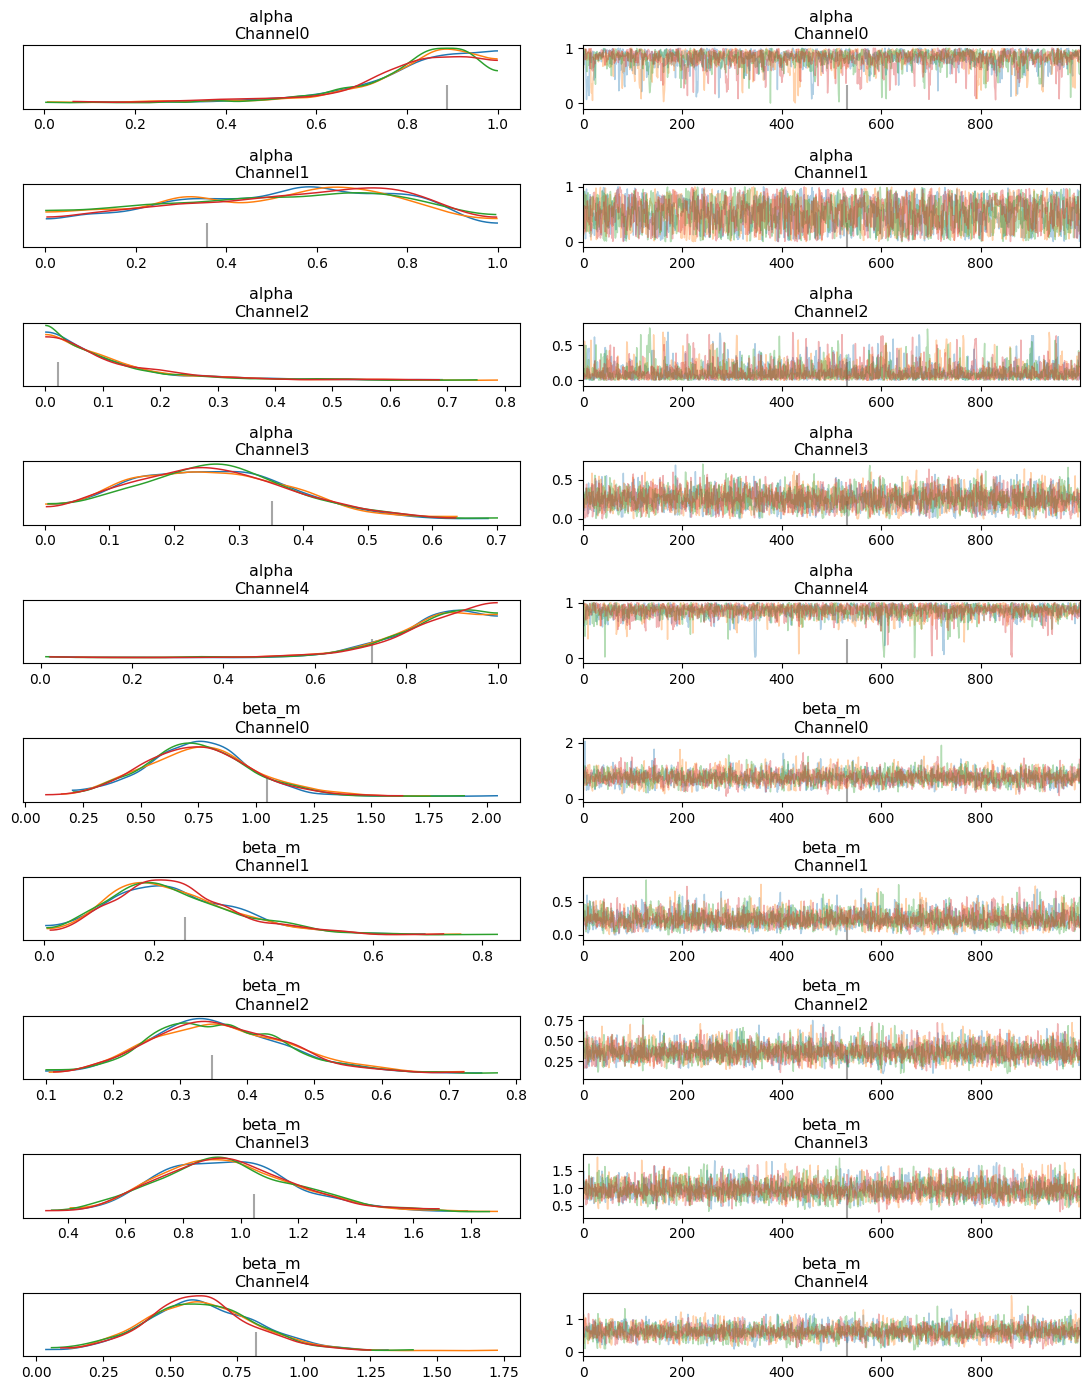

In [15]:
axes = az.plot_trace(trace, var_names=["alpha", "beta_m"], compact=False, figsize=(11, 14))
plt.tight_layout()
plt.show()

Trace plots (right column) show one wiggly line per chain, overlapping and
"fuzzy" with no trends or stuck patches — that's what healthy mixing looks
like. The left column is each chain's marginal posterior density; 4 chains
landing on top of each other is another visual version of "r_hat ≈ 1".

Sampling: [alpha, beta_gm_z, beta_m, ec, eta_m, gamma_c, gamma_gc_z, sigma, tau_g_z, tau_mu, tau_sigma, xi_c, y_obs]


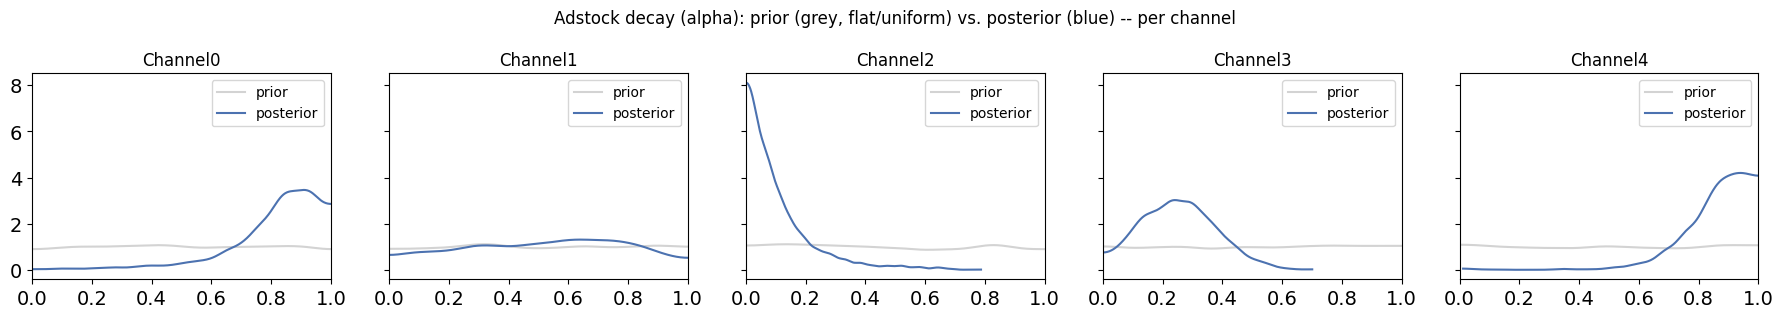

In [ ]:
#  Prior vs. posterior: the most direct evidence of "did the data

with mmm_model:
    prior_pred = pm.sample_prior_predictive(samples=2000, random_seed=42)

fig, axes = plt.subplots(1, n_channels, figsize=(18, 3.2), sharey=True)
for i, ch in enumerate(media_channels):
    az.plot_dist(prior_pred.prior["alpha"].values[..., i].flatten(), ax=axes[i],
                 color="lightgrey", label="prior")
    az.plot_dist(trace.posterior["alpha"].values[..., i].flatten(), ax=axes[i],
                 color="#4C72B0", label="posterior")
    axes[i].set_title(ch)
    axes[i].set_xlim(0, 1)
axes[0].legend()
fig.suptitle("Adstock decay (alpha): prior (grey, flat/uniform) vs. posterior (blue) -- per channel")
plt.tight_layout()
plt.show()

Sampling: [y_obs]


/usr/local/lib/python3.11/dist-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

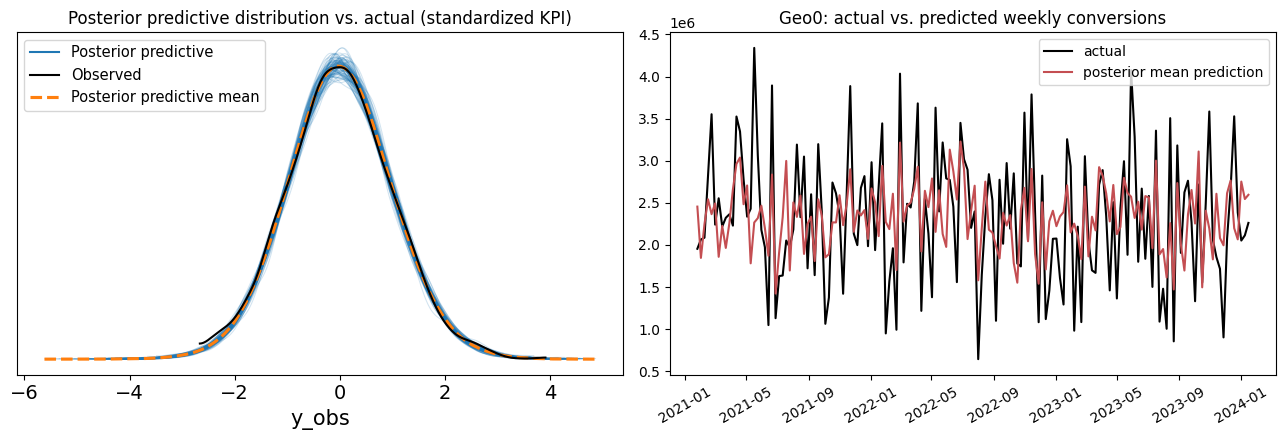

In [ ]:
with mmm_model:
    ppc = pm.sample_posterior_predictive(trace, random_seed=42)

y_pred_mean = ppc.posterior_predictive["y_obs"].mean(dim=("chain", "draw")).values  # (time, geo), scaled units

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))


az.plot_ppc(ppc, ax=axes[0], data_pairs={"y_obs": "y_obs"}, num_pp_samples=100)
axes[0].set_title("Posterior predictive distribution vs. actual (standardized KPI)")

g_idx = geos.index("Geo0")
pred_conv = (y_pred_mean[:, g_idx] * y_percap_std + y_percap_mean) * population[g_idx]
actual_conv = y_raw[:, g_idx]
axes[1].plot(times, actual_conv, label="actual", color="black")
axes[1].plot(times, pred_conv, label="posterior mean prediction", color="#C44E52")
axes[1].set_title("Geo0: actual vs. predicted weekly conversions")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [ ]:

resid = y_scaled - y_pred_mean
r2 = 1 - np.sum(resid**2) / np.sum((y_scaled - y_scaled.mean())**2)
print(f"R^2 (posterior mean fit, standardized KPI): {r2:.3f}")
print()
print("Sanity check only -- MMMs are not judged primarily on in-sample R^2")
print("(a model can fit well by overfitting geo/time noise and still give bad")
print("channel-level ROI estimates). What matters more is whether the")
print("individual channel posteriors above are informative and plausible,")
print("and -- ideally -- whether predictions hold up on held-out weeks,")
print("which we haven't set up here to keep this notebook focused.")

R^2 (posterior mean fit, standardized KPI): 0.385

Sanity check only -- MMMs are not judged primarily on in-sample R^2
(a model can fit well by overfitting geo/time noise and still give bad
channel-level ROI estimates). What matters more is whether the
individual channel posteriors above are informative and plausible,
and -- ideally -- whether predictions hold up on held-out weeks,
which we haven't set up here to keep this notebook focused.


In [ ]:
alpha_s = trace.posterior["alpha"].values        
ec_s = trace.posterior["ec"].values              
beta_gm_s = trace.posterior["beta_gm"].values    

n_chain, n_draw = alpha_s.shape[:2]
n_post = n_chain * n_draw
alpha_flat = alpha_s.reshape(n_post, n_channels)
ec_flat = ec_s.reshape(n_post, n_channels)
beta_gm_flat = beta_gm_s.reshape(n_post, n_geos, n_channels)

n_use = 200
idx = RNG.choice(n_post, size=n_use, replace=False)

contributions_conv = np.zeros((n_use, n_channels))  # total incremental conversions, per channel, per draw
for d, i in enumerate(idx):
    a = alpha_flat[i]                     # (channel,)
    weights = a[None, :] ** np.arange(l_max)[:, None]
    weights = weights / weights.sum(axis=0, keepdims=True)          # (l_max, channel)

    padded = np.concatenate([np.zeros((l_max - 1, n_geos, n_channels)), media_scaled], axis=0)
    adstocked = np.zeros_like(media_scaled)
    for lag in range(l_max):
        adstocked += padded[(l_max - 1 - lag):(l_max - 1 - lag) + n_times] * weights[lag][None, None, :]

    ec_i = ec_flat[i]
    saturated = adstocked ** 1.0 / (adstocked ** 1.0 + ec_i[None, None, :] ** 1.0)  # slope=1

    contribution_scaled = saturated * beta_gm_flat[i][None, :, :]    

    contribution_conv = contribution_scaled * y_percap_std * population[None, :, None]
    contributions_conv[d] = contribution_conv.sum(axis=(0, 1))

contrib_summary = pd.DataFrame({
    "channel": media_channels,
    "mean_incremental_conversions": contributions_conv.mean(axis=0),
    "hdi_3%": np.percentile(contributions_conv, 3, axis=0),
    "hdi_97%": np.percentile(contributions_conv, 97, axis=0),
})
contrib_summary

,channel,mean_incremental_conversions,hdi_3%,hdi_97%
0,Channel0,6.597640e+09,3.076250e+09,1.038619e+10
1,Channel1,1.668962e+09,4.444949e+08,3.225827e+09
2,Channel2,1.121042e+09,7.532525e+08,1.664679e+09
3,Channel3,6.584061e+09,4.248863e+09,9.402143e+09
4,Channel4,6.201743e+09,2.613951e+09,1.371513e+10


In [20]:
total_spend_by_channel = spend_raw.sum(axis=(0, 1))  # (channel,)

roi_draws = (contributions_conv * revenue_per_conv) / total_spend_by_channel[None, :]
cpik_draws = total_spend_by_channel[None, :] / contributions_conv

roi_summary = pd.DataFrame({
    "channel": media_channels,
    "total_spend": total_spend_by_channel,
    "mean_roi": roi_draws.mean(axis=0),
    "roi_hdi_3%": np.percentile(roi_draws, 3, axis=0),
    "roi_hdi_97%": np.percentile(roi_draws, 97, axis=0),
    "mean_cpik": cpik_draws.mean(axis=0),
})
roi_summary.round(3)

,channel,total_spend,mean_roi,roi_hdi_3%,roi_hdi_97%,mean_cpik
0,Channel0,4.050171e+07,3.258,1.519,5.129,0.007
1,Channel1,3.132030e+07,1.066,0.284,2.060,0.024
2,Channel2,1.207935e+07,1.856,1.247,2.756,0.011
3,Channel3,8.786036e+07,1.499,0.967,2.140,0.014
4,Channel4,4.773068e+07,2.599,1.095,5.747,0.009


**Take these numbers with real caveats**, which is itself part of
understanding the method rather than a footnote to skip:

- This is a deliberately simplified model (2 controls, no trend/seasonality
  term, no organic media, additive rather than Meridian's log-normal geo
  hierarchy, a plain Normal likelihood). Meridian's real model, which Part 2
  runs on this same dataset, includes more of these pieces — expect the ROI
  numbers to differ, sometimes by a lot, and that's expected and informative
  rather than a bug to chase.
- Simulated data like this doesn't ship with published "true" ROI values to
  grade ourselves against — the honest validation here is *did the model
  learn something informative* (Section 6) and *does it reproduce the
  observed data reasonably* (Section 7), not "did we recover a hidden
  ground truth."
- ROI credible intervals here are wide. That's a real, informative result,
  not a failure — with 5 channels sharing 156 weeks of variation, some
  channels (particularly ones that are simultaneously flighted, so their
  spend moves together) are inherently harder to disentangle than others.

## 9. Optional: the log-normal geo-hierarchy Meridian actually uses

Section 5 flagged one simplification: our `beta_gm = beta_m + eta_m * z` can,
in principle, go negative for a geo with an unlucky draw of `z`, which makes
no real-world sense for a media effect. Meridian's actual default avoids this
by working in log-space:

`beta_gm = beta_m * exp(eta_m * z)`  (with `z ~ Normal(0, 1)`, still
non-centered)

This guarantees `beta_gm > 0` for every geo, no matter what `z` is, while
keeping the same non-centered-friendly sampling geometry. The cell below
refits just this one piece as a quick comparison — expect very similar
results here, precisely because `eta_m` turned out small enough in Section 6
that the two parameterizations rarely disagree; the log-normal version is the
safer general-purpose default, which is why it's Meridian's default and not
just a stylistic choice.

In [21]:
with pm.Model(coords=coords) as mmm_model_lognormal:
    media_data = pm.Data("media_data", media_scaled, dims=("time", "geo", "channel"))
    controls_data = pm.Data("controls_data", controls_scaled, dims=("time", "geo", "control"))
    y_data = pm.Data("y_data", y_scaled, dims=("time", "geo"))

    alpha = pm.Uniform("alpha", 0, 1, dims="channel")
    ec = pm.TruncatedNormal("ec", mu=0.8, sigma=0.8, lower=0.1, upper=10, dims="channel")
    adstocked = geometric_adstock(media_data, alpha, l_max)
    saturated = hill_saturation(adstocked, ec, 1.0)

    beta_m = pm.HalfNormal("beta_m", sigma=5, dims="channel")
    eta_m = pm.HalfNormal("eta_m", sigma=1, dims="channel")
    beta_gm_z = pm.Normal("beta_gm_z", 0, 1, dims=("geo", "channel"))
    # log-normal hierarchy: beta_gm is guaranteed positive
    beta_gm = pm.Deterministic(
        "beta_gm", beta_m[None, :] * pm.math.exp(eta_m[None, :] * beta_gm_z), dims=("geo", "channel")
    )
    media_contribution = pm.math.sum(saturated * beta_gm[None, :, :], axis=-1)

    gamma_c = pm.Normal("gamma_c", 0, 5, dims="control")
    xi_c = pm.HalfNormal("xi_c", sigma=1, dims="control")
    gamma_gc_z = pm.Normal("gamma_gc_z", 0, 1, dims=("geo", "control"))
    gamma_gc = pm.Deterministic("gamma_gc", gamma_c[None, :] + xi_c[None, :] * gamma_gc_z, dims=("geo", "control"))
    controls_contribution = pm.math.sum(controls_data * gamma_gc[None, :, :], axis=-1)

    tau_mu = pm.Normal("tau_mu", 0, 5)
    tau_sigma = pm.HalfNormal("tau_sigma", sigma=5)
    tau_g_z = pm.Normal("tau_g_z", 0, 1, dims="geo")
    tau_g = pm.Deterministic("tau_g", tau_mu + tau_sigma * tau_g_z, dims="geo")

    mu = tau_g[None, :] + media_contribution + controls_contribution
    sigma = pm.HalfNormal("sigma", sigma=5)
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data, dims=("time", "geo"))

    trace_lognormal = pm.sample(draws=500, tune=500, chains=4, target_accept=0.9, random_seed=42)

az.summary(trace_lognormal, var_names=["alpha", "beta_m", "eta_m"])

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [alpha, ec, beta_m, eta_m, beta_gm_z, gamma_c, xi_c, gamma_gc_z, tau_mu, tau_sigma, tau_g_z, sigma]


/usr/local/lib/python3.11/dist-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/usr/local/lib/python3.11/dist-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow 
encountered in dot
  return 0.5 * np.dot(x, v_out)

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 894 seconds.


There were 113 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[Channel0],0.852,0.102,0.697,1.000,0.006,0.006,180.0,739.0,1.03
alpha[Channel1],0.421,0.286,0.007,0.904,0.038,0.010,36.0,21.0,1.08
alpha[Channel2],0.105,0.106,0.000,0.300,0.003,0.004,1413.0,1173.0,1.04
alpha[Channel3],0.298,0.144,0.042,0.585,0.026,0.015,36.0,41.0,1.08
alpha[Channel4],0.815,0.150,0.543,1.000,0.023,0.014,56.0,139.0,1.06
beta_m[Channel0],0.660,0.217,0.279,1.060,0.023,0.010,105.0,113.0,1.04
beta_m[Channel1],0.189,0.096,0.027,0.375,0.004,0.002,711.0,929.0,1.02
beta_m[Channel2],0.310,0.093,0.145,0.488,0.003,0.002,1081.0,986.0,1.00
beta_m[Channel3],0.922,0.231,0.491,1.352,0.007,0.007,1203.0,1208.0,1.02
beta_m[Channel4],0.498,0.218,0.092,0.858,0.035,0.023,40.0,25.0,1.07


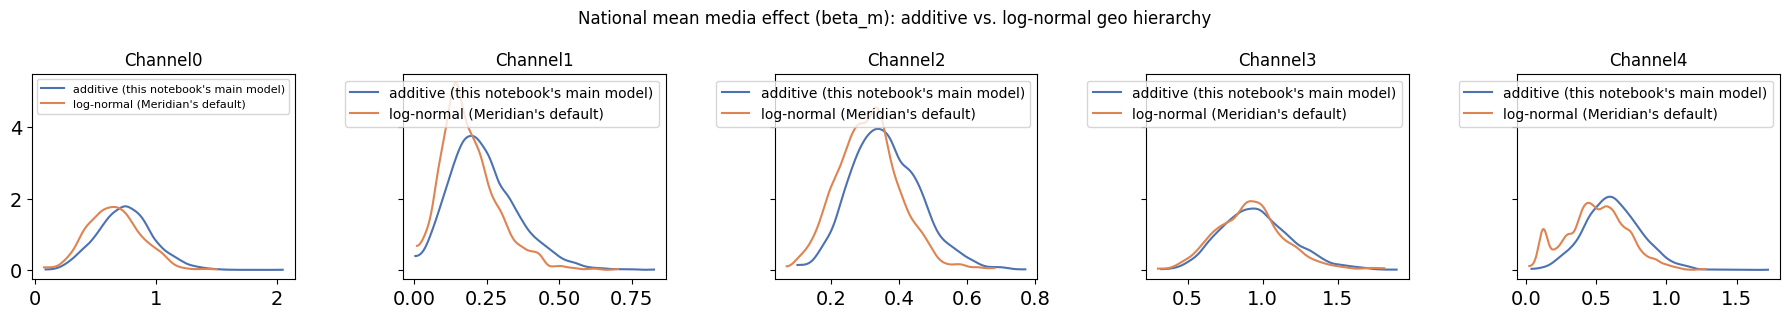

In [22]:
fig, axes = plt.subplots(1, n_channels, figsize=(18, 3.2), sharey=True)
for i, ch in enumerate(media_channels):
    az.plot_dist(trace.posterior["beta_m"].values[..., i].flatten(), ax=axes[i],
                 color="#4C72B0", label="additive (this notebook's main model)")
    az.plot_dist(trace_lognormal.posterior["beta_m"].values[..., i].flatten(), ax=axes[i],
                 color="#DD8452", label="log-normal (Meridian's default)")
    axes[i].set_title(ch)
axes[0].legend(fontsize=8)
fig.suptitle("National mean media effect (beta_m): additive vs. log-normal geo hierarchy")
plt.tight_layout()
plt.show()